# Exp 19 — Inference Demo: Octopus Presence per Frame

Extract frames at 1fps from a clip, run the CLIP MLP classifier on each, visualise results.

In [ ]:
import subprocess, sys, tempfile
from pathlib import Path

import pkg_resources, packaging, packaging.version, packaging.specifiers, packaging.requirements
pkg_resources.packaging = packaging

import clip
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

PROJECT   = Path(".").resolve().parent
CKPT_PATH = PROJECT / "weights" / "clip_mlp_best.pt"
CLIP_PATH = PROJECT / "data" / "octopus_clips" / "2026-03-12_0600_w3_Right_Back_15:48-16:08.mp4"

THRESHOLD = 0.7   # P(visible) must exceed this to count as "octopus present"

device = (
    "mps"  if torch.backends.mps.is_available() else
    "cuda" if torch.cuda.is_available()         else
    "cpu"
)
print(f"Device    : {device}")
print(f"Clip      : {CLIP_PATH.name}")
print(f"Threshold : {THRESHOLD}")

## 1 — Load model

In [2]:
ckpt     = torch.load(CKPT_PATH, map_location=device)
feat_dim = ckpt["feat_dim"]
arch     = ckpt.get("arch", "linear")

def build_classifier(feat_dim, arch):
    if arch == "linear":
        return nn.Linear(feat_dim, 2)
    hidden = [int(x) for x in arch.replace("mlp_", "").split("_")]
    dims, layers = [feat_dim] + hidden + [2], []
    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i+1]))
        if i < len(dims) - 2:
            layers += [nn.ReLU(), nn.Dropout(0.3)]
    return nn.Sequential(*layers)

clip_model, preprocess = clip.load(ckpt["clip_model"], device=device)
clip_model.eval()

classifier = build_classifier(feat_dim, arch).to(device)
classifier.load_state_dict(ckpt["state_dict"])
classifier.eval()

print(f"CLIP   : {ckpt['clip_model']}")
print(f"Arch   : {arch}")
print(f"Test acc (training): {ckpt.get('test_acc', 0):.1%}")

CLIP   : ViT-B/32
Arch   : mlp_256_64
Test acc (training): 98.1%


## 2 — Extract frames at 1fps

In [3]:
tmpdir = tempfile.mkdtemp()
pattern = str(Path(tmpdir) / "frame_%04d.jpg")

cmd = [
    "ffmpeg", "-y", "-loglevel", "error",
    "-i", str(CLIP_PATH),
    "-vf", "fps=1",
    "-q:v", "2",
    pattern,
]
subprocess.run(cmd, check=True)

frame_paths = sorted(Path(tmpdir).glob("frame_*.jpg"))
print(f"{len(frame_paths)} frames extracted")

20 frames extracted


## 3 — Run inference on each frame

In [ ]:
frames, probs, preds = [], [], []

for path in frame_paths:
    img = Image.open(path).convert("RGB")
    frames.append(img)

    x = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = clip_model.encode_image(x).float()
        feat = feat / feat.norm(dim=-1, keepdim=True)
        logit = classifier(feat)
        prob  = torch.softmax(logit, dim=1)[0, 1].item()  # P(visible)

    probs.append(prob)
    preds.append("visible" if prob >= THRESHOLD else "hidden")
    print(f"  frame {len(probs):02d}  P(visible)={prob:.2f}  → {preds[-1]}")

## 4 — Confidence timeline

In [ ]:
seconds = list(range(1, len(probs) + 1))
colors  = ["#4caf50" if p >= THRESHOLD else "#e05555" for p in probs]

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.bar(seconds, probs, color=colors, width=0.8)
ax.axhline(THRESHOLD, color="white", linestyle="--", linewidth=1, alpha=0.7, label=f"threshold={THRESHOLD}")
ax.set_xlim(0.5, len(probs) + 0.5)
ax.set_ylim(0, 1)
ax.set_xlabel("Second")
ax.set_ylabel("P(octopus visible)")
ax.set_title(f"Inference on {CLIP_PATH.name}")
ax.set_facecolor("#1a1a1a"); fig.patch.set_facecolor("#111")
ax.tick_params(colors="#aaa"); ax.yaxis.label.set_color("#aaa"); ax.xaxis.label.set_color("#aaa")
ax.title.set_color("#ddd")
vis_patch = mpatches.Patch(color="#4caf50", label="visible (≥0.7)")
hid_patch = mpatches.Patch(color="#e05555", label="hidden (<0.7)")
ax.legend(handles=[vis_patch, hid_patch], facecolor="#222", labelcolor="#ddd")
plt.tight_layout()
plt.show()

n_vis = sum(1 for p in preds if p == "visible")
print(f"\nSummary: {n_vis}/{len(preds)} frames → octopus visible ({n_vis/len(preds):.0%})")

## 5 — Frame grid with predictions

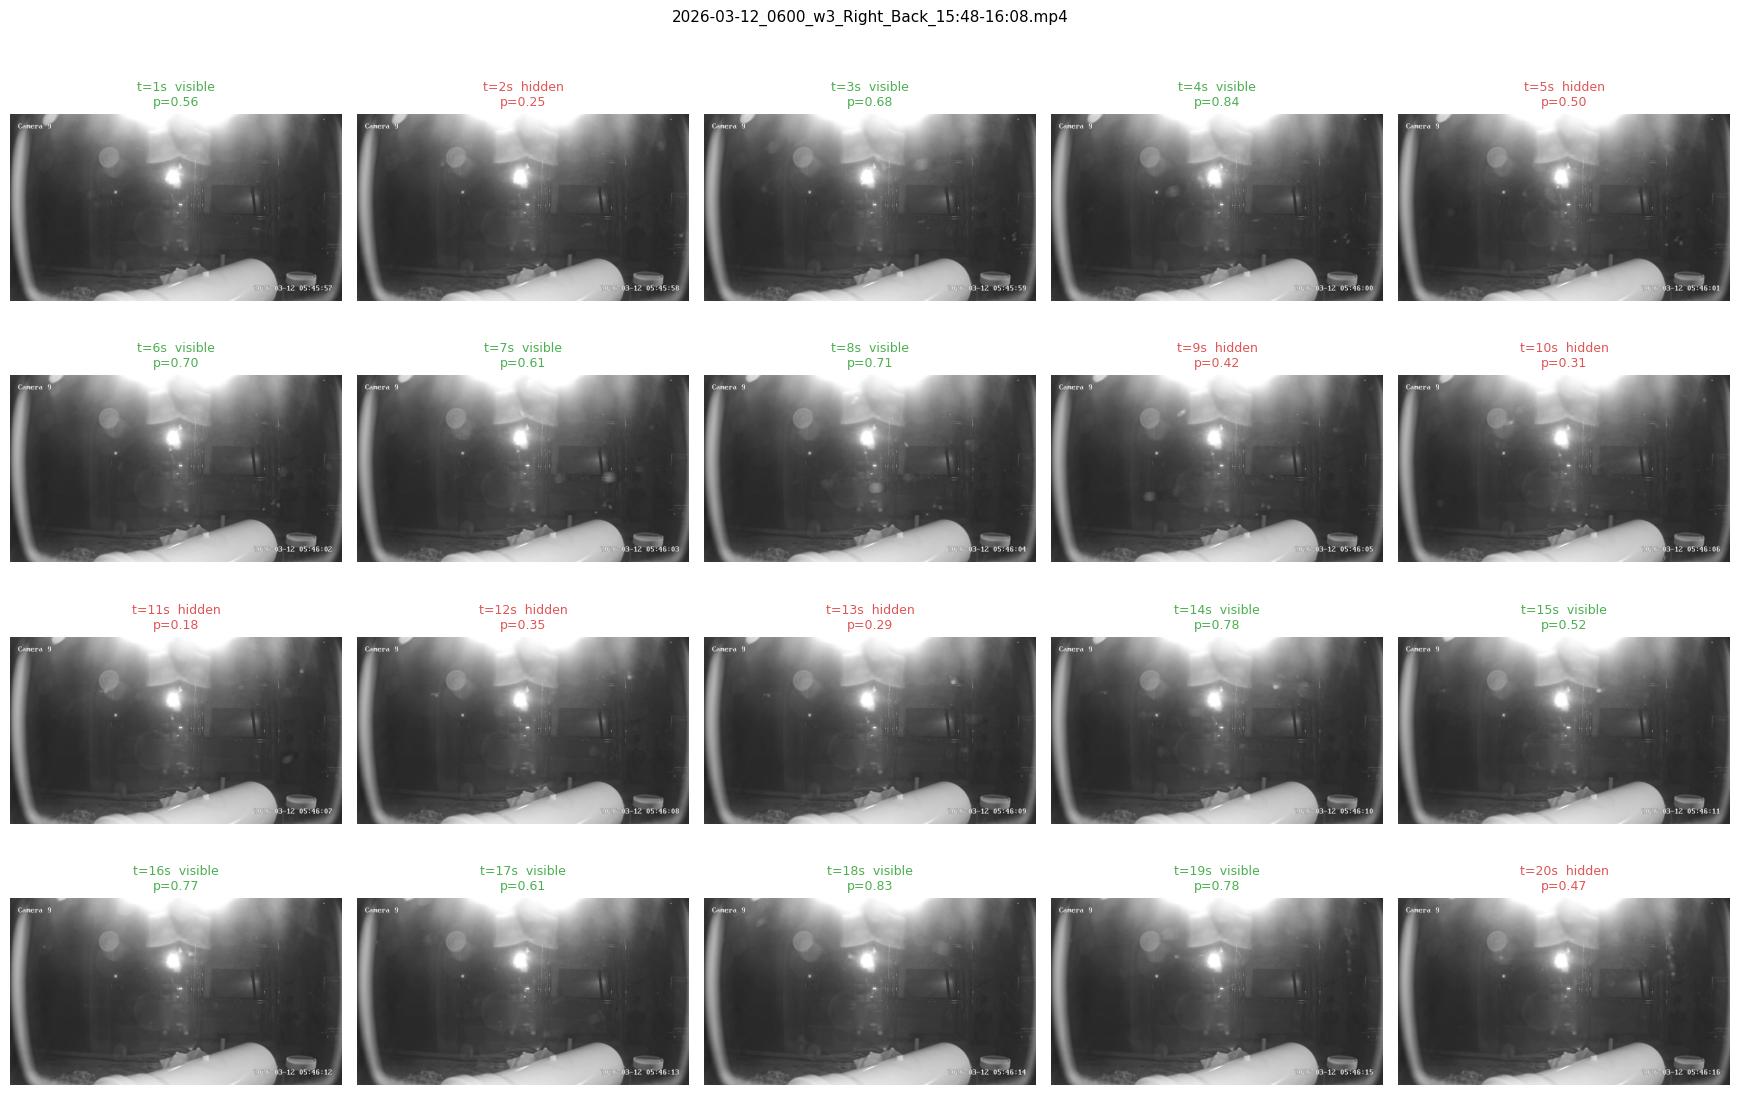

In [6]:
n    = len(frames)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 2.8))
axes = np.array(axes).flatten()

for i, (img, prob, pred) in enumerate(zip(frames, probs, preds)):
    ax = axes[i]
    ax.imshow(img)
    col = "#4caf50" if pred == "visible" else "#e05555"
    ax.set_title(f"t={i+1}s  {pred}\np={prob:.2f}", fontsize=9, color=col)
    ax.axis("off")
    # Coloured border
    for spine in ax.spines.values():
        spine.set_edgecolor(col)
        spine.set_linewidth(3)
        spine.set_visible(True)

for ax in axes[n:]:
    ax.axis("off")

plt.suptitle(CLIP_PATH.name, fontsize=11, y=1.01)
plt.tight_layout()
plt.show()